## Make images

In [1]:
import radmc3d_tools
import radmc3dPy
import numpy as np

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/different_viscs_run_ppdisk_fargo3d")
# Don't touch. 


## Creating the dust_temp.dat file

In [3]:
## instead of running radmc3d mctherm (which takes a long time and is not relevant for our wavelength range) we define the 
## dust_temperature.dat file on our own.
path = "/home/hd/hd_hd/hd_cu284/jupyter notebooks/different_viscs_run_ppdisk_fargo3d"
rho = np.fromfile(f"{path}/dust_density.inp", sep="\n")  # adjust separator if needed
n_cells = len(rho)-3

# Create dust temperatures
dust_temp = np.ones(shape=n_cells)
dust_temp *= 10  # arbitrary temperature

# Write to file in RADMC-3D format
with open(f"{path}/dust_temperature.dat", "w") as f:
    f.write("1\n")            # number of dust species
    f.write(f"{n_cells}\n")   # number of cells
    f.write("1\n")            # number of components (usually 1)
    # Now write the temperatures in scientific notation
    for temp in dust_temp:
        f.write(f" {temp:.6e}\n")

In [4]:
dust_temp= np.fromfile(f"{path}/dust_temperature.dat", sep="\n ")
print(dust_temp)

[1.000000e+00 2.605056e+06 1.000000e+00 ... 1.000000e+01 1.000000e+01
 1.000000e+01]


In [6]:
from radmc3dPy.image import makeImage, readImage, plotImage

In [7]:
import os
import sys

class silence_stdout_stderr:
    def __enter__(self):
        # Save original FDs
        self.old_stdout = os.dup(1)
        self.old_stderr = os.dup(2)

        # Redirect both to /dev/null
        self.devnull = os.open(os.devnull, os.O_WRONLY)
        os.dup2(self.devnull, 1)
        os.dup2(self.devnull, 2)

    def __exit__(self, *args):
        # Restore original FDs
        os.dup2(self.old_stdout, 1)
        os.dup2(self.old_stderr, 2)

        os.close(self.devnull)
        os.close(self.old_stdout)
        os.close(self.old_stderr)

## Images for 10µm

In [ ]:
with silence_stdout_stderr():
    makeImage(npix=150, incl=0.0, wav=10.0, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_0 = readImage()

In [ ]:

plotImage(image_0, log=True, maxlog=10)

In [ ]:
with silence_stdout_stderr():
    makeImage(npix=150, incl=30.0, wav=10.0, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_30 = readImage()

In [ ]:
plotImage(image_30, log=True, maxlog=10)

In [ ]:
with silence_stdout_stderr():
    makeImage(npix=150, incl=30.0, wav=10.0, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_60 = readImage()

In [ ]:
plotImage(image_60, log=True, maxlog=10)

In [ ]:
with silence_stdout_stderr():
    makeImage(npix=150, incl=90.0, wav=10.0, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_90 = readImage()

In [ ]:
plotImage(image_90, log=True, maxlog=10)

In [ ]:

plotImage(image_0, log=True, maxlog=20)

plotImage(image_30, log=True, maxlog=20)

plotImage(image_60, log=True, maxlog=20)
plotImage(image_90, log=True, maxlog=20)

# K-Band: 2.2µm

In [23]:
import subprocess
import os
from radmc3dPy.image import makeImage

# Save original environment
with silence_stdout_stderr():
    makeImage(npix=150, incl=0.0, wav=2.2, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K0 = readImage()

Executing RADMC-3D Command:
radmc3d image npix 150 incl 0.0 sizeau 300.0 lambda 2.2 phi 0.0 posang 15.0 pointau 0.0 0.0 0.0 fluxcons nostar
Reading image.out


In [24]:
with silence_stdout_stderr():
    makeImage(npix=150, incl=30.0, wav=2.2, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K30 = readImage()

Executing RADMC-3D Command:
radmc3d image npix 150 incl 30.0 sizeau 300.0 lambda 2.2 phi 0.0 posang 15.0 pointau 0.0 0.0 0.0 fluxcons nostar
Reading image.out


In [25]:
with silence_stdout_stderr():
    makeImage(npix=150, incl=60.0, wav=2.2, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K60 = readImage()

Executing RADMC-3D Command:
radmc3d image npix 150 incl 60.0 sizeau 300.0 lambda 2.2 phi 0.0 posang 15.0 pointau 0.0 0.0 0.0 fluxcons nostar
Reading image.out


In [26]:
with silence_stdout_stderr():    
    makeImage(npix=150, incl=90.0, wav=2.2, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K90 = readImage()

Executing RADMC-3D Command:
radmc3d image npix 150 incl 90.0 sizeau 300.0 lambda 2.2 phi 0.0 posang 15.0 pointau 0.0 0.0 0.0 fluxcons nostar
Reading image.out


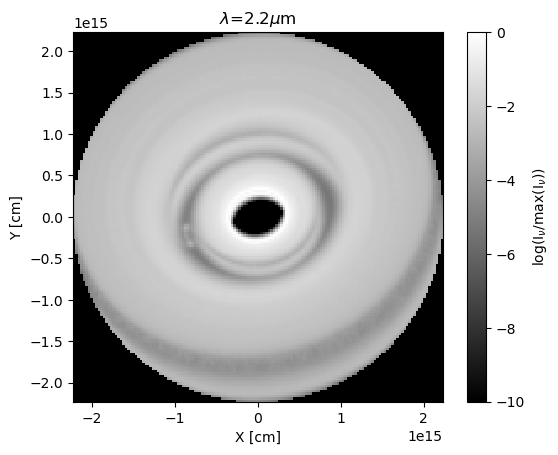

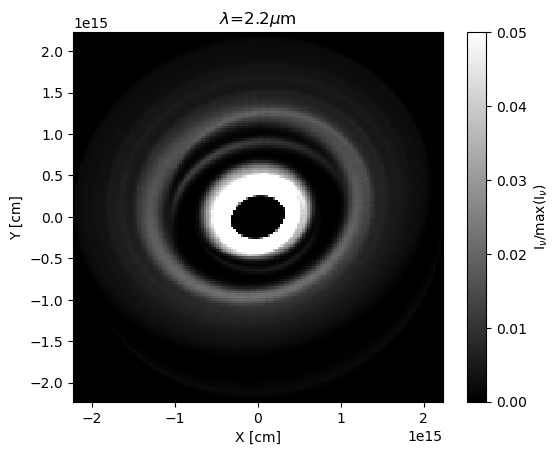

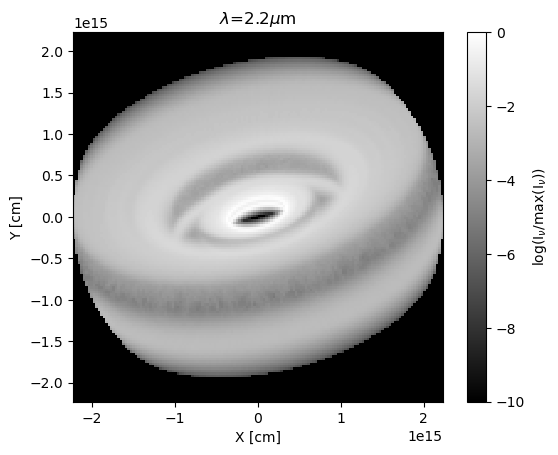

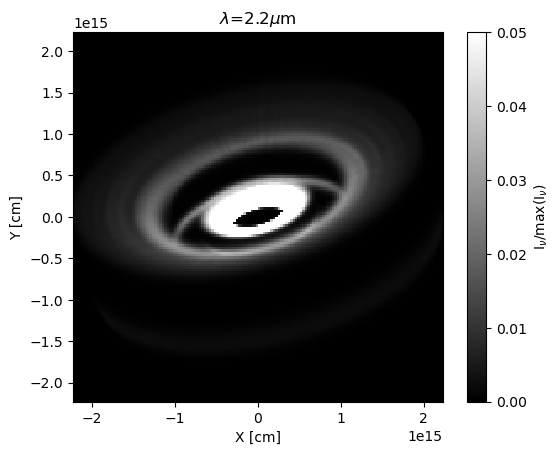

In [27]:
# alpha = 1e-4 with spiral
plotImage(image_K30,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K30,saturate=0.05)
plotImage(image_K60, log=True, maxlog=10)#saturate=0.1)#, 
plotImage(image_K60, saturate=0.05)

images = [image_K0, image_K30, image_K60, image_K90]
#np.save("images_a1e-4_spiral",images, allow_pickle=True)
#img = np.load("images_a1e-4.npy", allow_pickle=True)
#image_K0, image_K30, image_K60, image_K90 = img

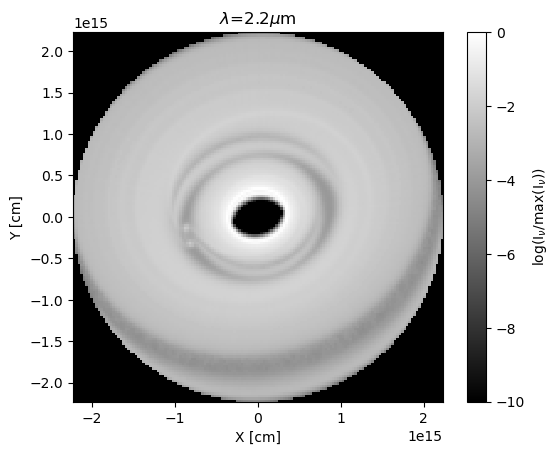

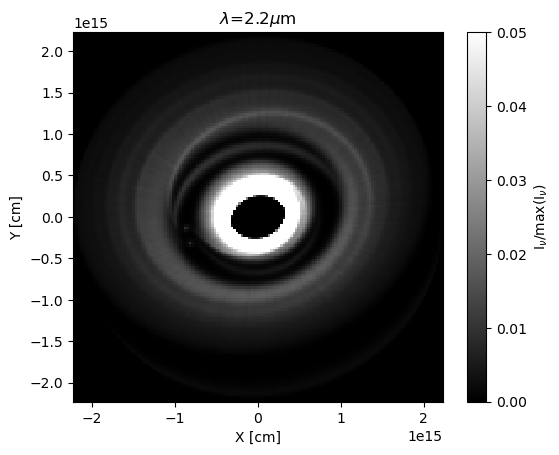

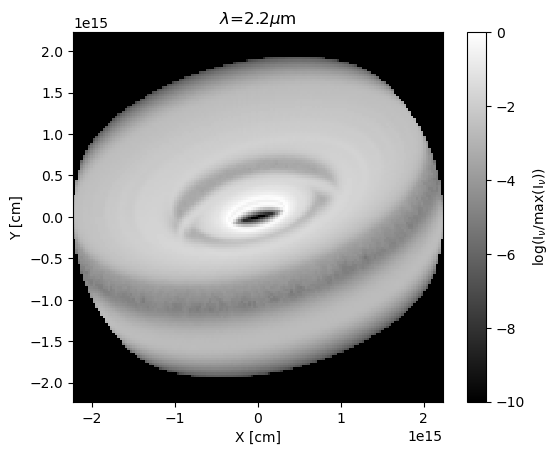

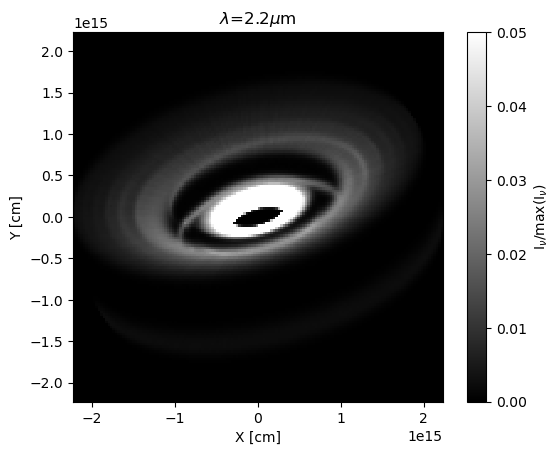

In [22]:
# alpha = 1e-3 with spiral
plotImage(image_K30,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K30,saturate=0.05)
plotImage(image_K60, log=True, maxlog=10)#saturate=0.1)#, 
plotImage(image_K60, saturate=0.05)

images = [image_K0, image_K30, image_K60, image_K90]
#np.save("images_a1e-3_spiral",images, allow_pickle=True)
#img = np.load("images_a1e-4.npy", allow_pickle=True)
#image_K0, image_K30, image_K60, image_K90 = img

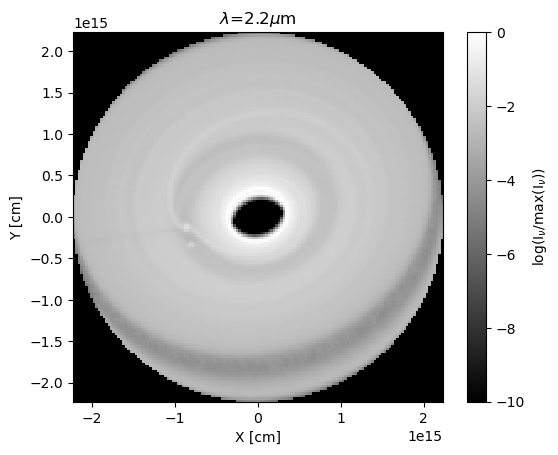

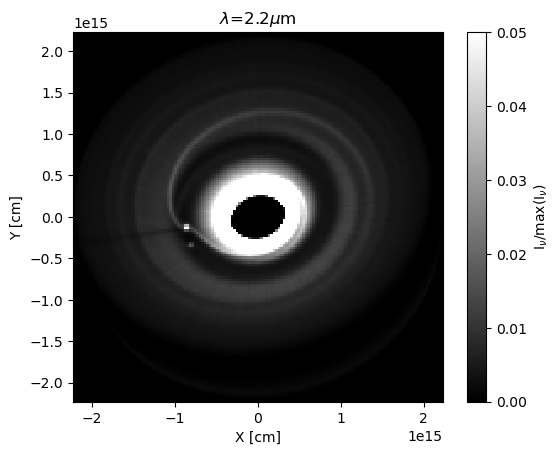

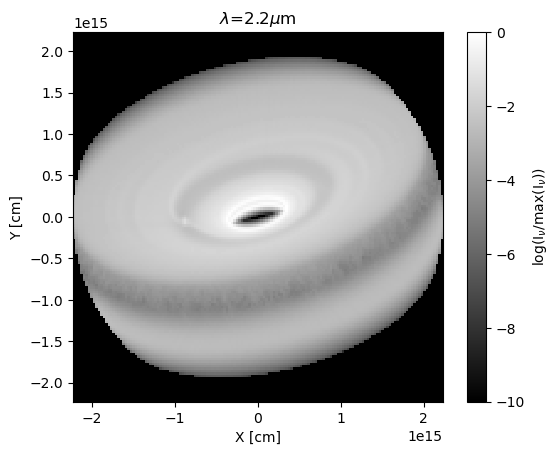

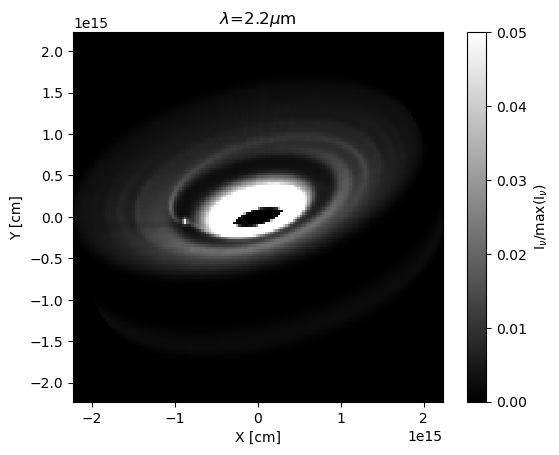

In [17]:
# alpha = 1e-2 with spiral
plotImage(image_K30,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K30,saturate=0.05)
plotImage(image_K60, log=True, maxlog=10)#saturate=0.1)#, 
plotImage(image_K60, saturate=0.05)

images = [image_K0, image_K30, image_K60, image_K90]
#np.save("images_a1e-2_spiral",images, allow_pickle=True)
#img = np.load("images_a1e-4.npy", allow_pickle=True)
#image_K0, image_K30, image_K60, image_K90 = img

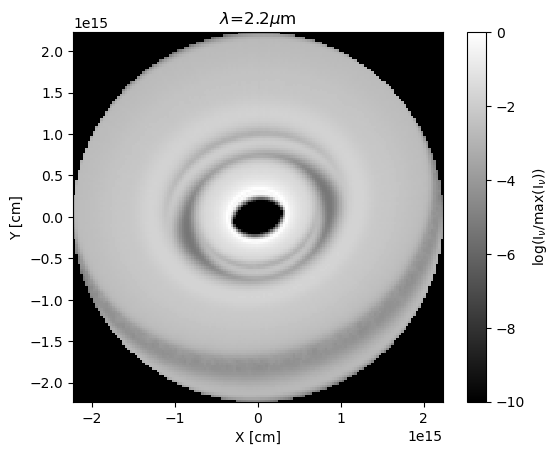

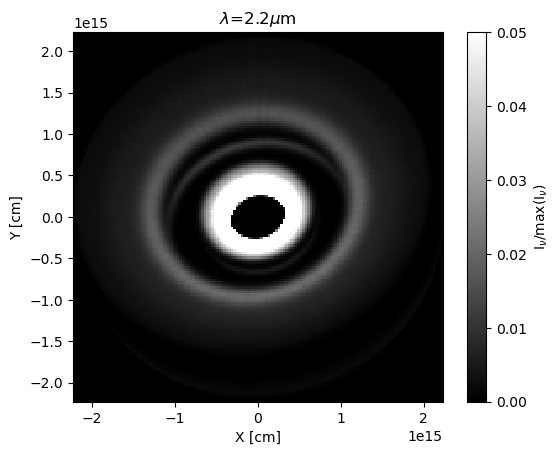

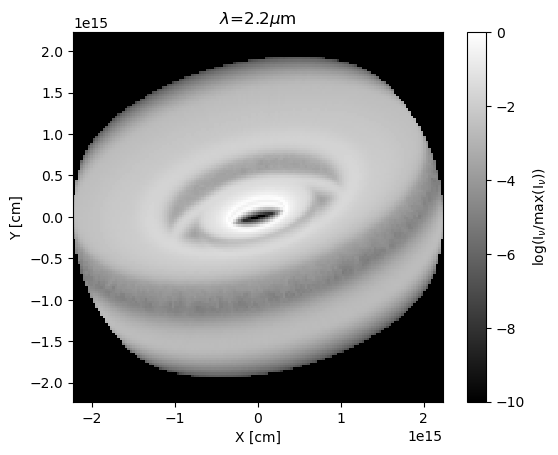

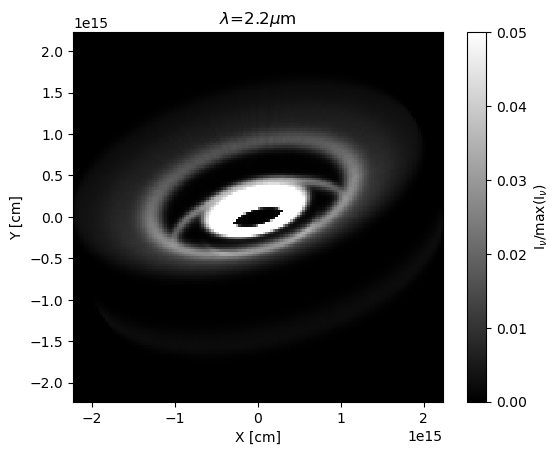

In [15]:
# alpha = 1e-4
plotImage(image_K30,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K30,saturate=0.05)
plotImage(image_K60, log=True, maxlog=10)#saturate=0.1)#, 
plotImage(image_K60, saturate=0.05)

images = [image_K0, image_K30, image_K60, image_K90]
#np.save("images_a1e-4",images, allow_pickle=True)
#img = np.load("images_a1e-4.npy", allow_pickle=True)
#image_K0, image_K30, image_K60, image_K90 = img

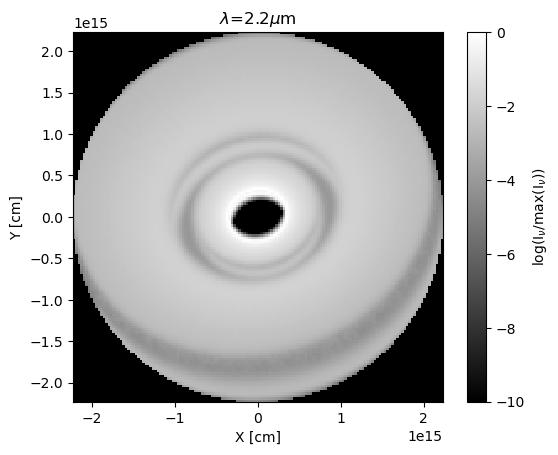

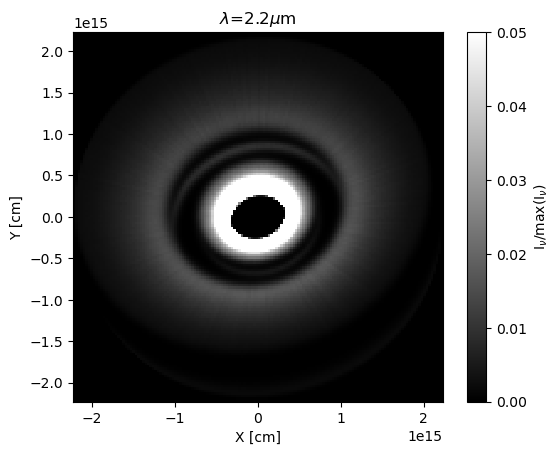

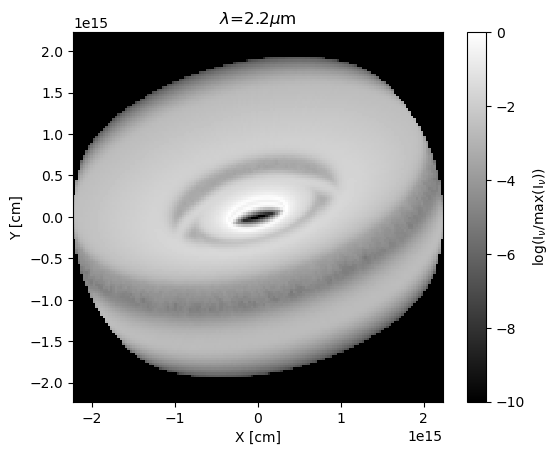

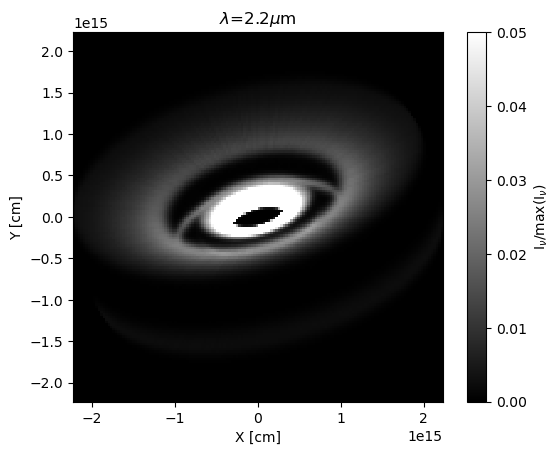

In [21]:
# alpha = 1e-3
plotImage(image_K30,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K30,saturate=0.05)
plotImage(image_K60, log=True, maxlog=10)#saturate=0.1)#, 
plotImage(image_K60, saturate=0.05)

images = [image_K0, image_K30, image_K60, image_K90]
#np.save("images_a1e-3",images, allow_pickle=True)
#img = np.load("images_a1e-4.npy", allow_pickle=True)
#image_K0, image_K30, image_K60, image_K90 = img

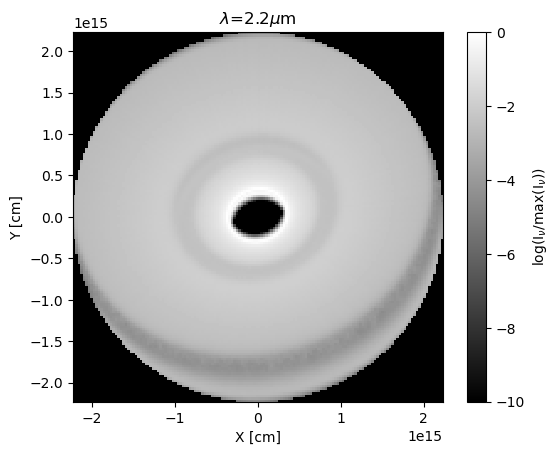

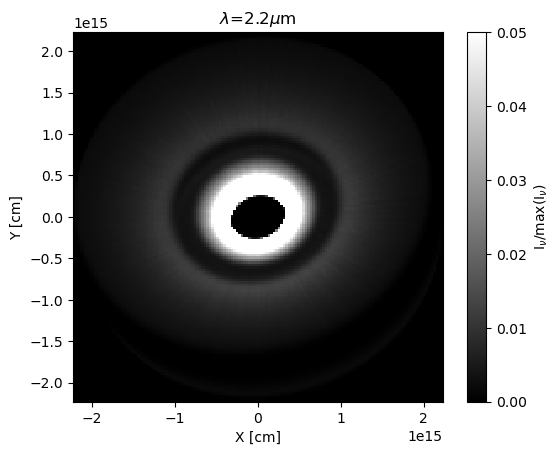

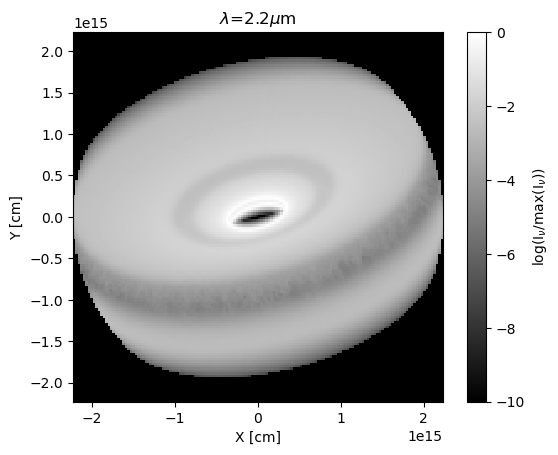

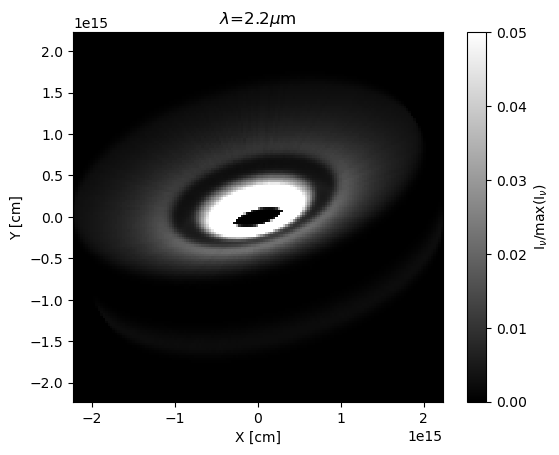

In [27]:
# alpha = 1e-2
plotImage(image_K30,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K30,saturate=0.05)
plotImage(image_K60, log=True, maxlog=10)#saturate=0.1)#, 
plotImage(image_K60, saturate=0.05)

images = [image_K0, image_K30, image_K60, image_K90]
#np.save("images_a1e-2",images, allow_pickle=True)
#img = np.load("images_a1e-4.npy", allow_pickle=True)
#image_K0, image_K30, image_K60, image_K90 = img

In [ ]:

plotImage(image_K0, log=True, maxlog=15)

plotImage(image_K30, log=True, maxlog=15)

plotImage(image_K60, log=True, maxlog=15)
plotImage(image_K90, log=True, maxlog=15)

# H-Band: 1.65µm

In [ ]:
import subprocess
import os
from radmc3dPy.image import makeImage

# Save original environment
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=0.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H0 = readImage()

In [ ]:
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=30.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H30 = readImage()

In [ ]:
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=60.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H60 = readImage()

In [ ]:
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=90.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H90 = readImage()

In [ ]:

plotImage(image_H0, log=True, maxlog=20)

plotImage(image_H30, log=True, maxlog=20)

plotImage(image_H60, log=True, maxlog=20)
plotImage(image_H90, log=True, maxlog=20)

In [ ]:
images = [image_0,image_30,image_60,image_90, image_K0, image_K30, image_K60, image_K90, image_H0, image_H30, image_H60, image_H90]
np.save("images",images, allow_pickle=True)

In [ ]:
import numpy as np
from radmc3dPy.image import makeImage, plotImage
img = np.load("images.npy", allow_pickle=True)

In [ ]:
plotImage(img[4], log=True, maxlog=10, saturate=1e-5)